In [1]:
!pip install splink

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 21.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.0/797.0 kB 14.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 23.8 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 23.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 673.9/673.9 kB 11.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [splink]2m5/6 [splink]]


In [64]:
!pip install spacy 
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 22.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.8/656.8 kB 4.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 844.4/844.4 kB 15.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 21.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [spacy]m15/16 [spacy]]

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 148, in _get_module_details
  File "<fro

In [65]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re as re
import thefuzz
import splink.comparison_library as cl
import spacy


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/envs/llj_revised/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/envs/llj_revised/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/envs/llj_revised/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.

In [ ]:
names = pd.read_csv('/Users/matt/Desktop/Patent Litigation Analysis/data/raw/names.csv',
                    dtype={'case_row_id': str},
                    low_memory=False)

# drop
names = names[~names['case_row_id'].str.contains('#Docket Text', na=False)]

# now convert to int
names['case_row_id'] = names['case_row_id'].astype(int)
cases=pd.read_csv('/Users/matt/Desktop/Patent Litigation Analysis/data/processed/cases/cases_cleaned_v3.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/matt/Desktop/Patent Litigation Analysis/data/processed/cases/cases_cleaned_v3.csv'

In [19]:
names['identifier'] = names['case_row_id'].map(cases.set_index('case_row_id')['identifier'])

In [16]:
print("names case_row_id sample:", names['case_row_id'].head())
print("cases case_row_id sample:", cases['case_row_id'].head())


names case_row_id sample: 0    1
1    3
2    4
3    5
4    6
Name: case_row_id, dtype: str
cases case_row_id sample: 0    33737.0
1    72268.0
2    83871.0
3    34070.0
4    52743.0
Name: case_row_id, dtype: str


In [2]:
names.to_csv('/Users/matt/Desktop/Patent Litigation Analysis/data/processed/names/names_cleaned_v2.csv', index=False)

NameError: name 'names' is not defined

In [4]:
names=pd.read_csv('/Users/matt/Desktop/Patent Litigation Analysis/data/processed/names/names_cleaned_v2.csv')

In [5]:
dupes = names.groupby(['party_type', 'name', 'identifier','name_long']).size().reset_index(name='count')
dupes = dupes[dupes['count'] > 1].sort_values('count', ascending=False)

print(f"Total duplicate groups: {len(dupes)}")
print(f"Total duplicate entries: {dupes['count'].sum()}")
print(dupes.head(20).to_string())

Total duplicate groups: 0
Total duplicate entries: 0
Empty DataFrame
Columns: [party_type, name, identifier, name_long, count]
Index: []


In [6]:
names.drop_duplicates(subset=['party_type', 'name', 'identifier'], keep='first', inplace=True)

# recalculate AFTER dropping
dupes = names.groupby(['party_type', 'name', 'identifier', 'name_long']).size().reset_index(name='count')
dupes = dupes[dupes['count'] > 1].sort_values('count', ascending=False)

print(f"Total duplicate groups: {len(dupes)}")
print(f"Total duplicate entries: {dupes['count'].sum()}")
print(dupes.head(20).to_string())

Total duplicate groups: 0
Total duplicate entries: 0
Empty DataFrame
Columns: [party_type, name, identifier, name_long, count]
Index: []


In [8]:
names['name'] = names['name'].str.replace(r'^[\-\.\&\s]+', '', regex=True)
# check for any remaining leading symbols
mask = names['name'].str.match(r'^[\-\.\&]', na=False)
print(names[mask]['name'].head(20))

Series([], Name: name, dtype: str)


In [7]:
print(f"Total unique names: {names['name'].nunique()}")

Total unique names: 175475


In [8]:
from thefuzz import fuzz

# get names that appear more than 100 times
name_counts = names['name'].value_counts()
high_freq_names = name_counts[name_counts >= 100].index.tolist()
print(f"Names appearing 100+ times: {len(high_freq_names)}")

# match only these
results = []

for i, name1 in enumerate(high_freq_names):
    for name2 in high_freq_names[i+1:]:
        score = fuzz.token_sort_ratio(name1, name2)
        if score >= 85:
            results.append({
                'name1': name1,
                'name2': name2, 
                'score': score,
                'count1': name_counts[name1],
                'count2': name_counts[name2]
            })

matches = pd.DataFrame(results).sort_values('score', ascending=False)
print(f"Potential matches found: {len(matches)}")
print(matches.to_string())

Names appearing 100+ times: 324
Potential matches found: 171
                                           name1                                        name2  score  count1  count2
0                                           Does                                         DOES    100    1484     381
1                                     Apple Inc.                                    Apple Inc    100    1116     544
2                                     Apple Inc.                                  Apple, Inc.    100    1116     228
3                                 Uniloc USA Inc                              Uniloc USA, Inc    100     600     209
4                                 Uniloc USA Inc                             Uniloc USA, Inc.    100     600     158
5                                    Pfizer Inc.                                 Pfizer, Inc.    100     595     376
6                        Hewlett-Packard Company                      HEWLETT PACKARD COMPANY    100     585     303
8  

In [ ]:
#consolidation map
consolidation_map = {}

for _, row in matches[matches['score'] >= 97].iterrows():
    # keep the more frequent name as the canonical version
    if row['count1'] >= row['count2']:
        consolidation_map[row['name2']] = row['name1']
    else:
        consolidation_map[row['name1']] = row['name2']

print(f"Names to be consolidated: {len(consolidation_map)}")
print("\nConsolidation mapping:")
for old, new in consolidation_map.items():
    print(f"  '{old}' → '{new}'")

# apply 
names['name_consolidated'] = names['name'].map(consolidation_map).fillna(names['name'])

# verify
print(f"\nOriginal unique names: {names['name'].nunique()}")
print(f"Consolidated unique names: {names['name_consolidated'].nunique()}")

Names to be consolidated: 75

Consolidation mapping:
  'DOES' → 'Does'
  'Apple Inc' → 'Apple Inc.'
  'Apple, Inc.' → 'Apple Inc'
  'Uniloc USA, Inc' → 'Uniloc USA Inc'
  'Uniloc USA, Inc.' → 'Uniloc USA, Inc'
  'Pfizer, Inc.' → 'Pfizer Inc.'
  'HEWLETT PACKARD COMPANY' → 'Hewlett-Packard Company'
  'LG Electronics Inc' → 'LG Electronics, Inc.'
  'Samsung Electronics Co Ltd' → 'Samsung Electronics Co., Ltd.'
  'SAMSUNG ELECTRONICS CO., LTD.' → 'Samsung Electronics Co Ltd'
  'ArrivalStar S A' → 'ArrivalStar S.A.'
  'Dell Inc' → 'Dell Inc.'
  'Dell, Inc.' → 'Dell Inc'
  'SAMSUNG ELECTRONICS AMERICA, INC.' → 'Samsung Electronics America, Inc.'
  'Samsung Electronics America Inc' → 'SAMSUNG ELECTRONICS AMERICA, INC.'
  'Teva Pharmaceuticals USA Inc' → 'Teva Pharmaceuticals USA, Inc.'
  'TEVA PHARMACEUTICALS USA, INC.' → 'Teva Pharmaceuticals USA Inc'
  'Teva Pharmaceuticals USA Inc.' → 'TEVA PHARMACEUTICALS USA, INC.'
  'HTC AMERICA, INC.' → 'HTC America Inc'
  'Mylan Pharmaceuticals Inc.'

In [10]:
name_counts2 = names['name_consolidated'].value_counts()
high_freq_names = name_counts2[name_counts2 >= 100].index.tolist()
print(f"Names appearing 100+ times: {len(high_freq_names)}")

# match only these
results = []

for i, name1 in enumerate(high_freq_names):
    for name2 in high_freq_names[i+1:]:
        score = fuzz.token_sort_ratio(name1, name2)
        if score >= 85:
            results.append({
                'name1': name1,
                'name2': name2, 
                'score': score,
                'count1': name_counts[name1],
                'count2': name_counts[name2]
            })

matches = pd.DataFrame(results).sort_values('score', ascending=False)
print(f"Potential matches found: {len(matches)}")
print(matches.to_string())

Names appearing 100+ times: 264
Potential matches found: 64
                                     name1                                 name2  score  count1  count2
0                               Apple Inc.                             Apple Inc    100    1116     544
1        Samsung Electronics America, Inc.     SAMSUNG ELECTRONICS AMERICA, INC.    100     509     419
2            Samsung Electronics Co., Ltd.            Samsung Electronics Co Ltd    100     547     380
3           Teva Pharmaceuticals USA, Inc.          Teva Pharmaceuticals USA Inc    100     482     416
4           Teva Pharmaceuticals USA, Inc.        TEVA PHARMACEUTICALS USA, INC.    100     482     187
5                                Dell Inc.                              Dell Inc    100     528     315
11               MYLAN PHARMACEUTICALS INC           Mylan Pharmaceuticals, Inc.    100     406     305
8                           Uniloc USA Inc                       Uniloc USA, Inc    100     600     209
15  

In [ ]:
from thefuzz import fuzz

# Union-Find implementation
class UnionFind:
    def __init__(self):
        self.parent = {}
    
    def find(self, x):
        if x not in self.parent:
            self.parent[x] = x
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    
    def union(self, x, y):
        px, py = self.find(x), self.find(y)
        if px != py:
            self.parent[px] = py

uf = UnionFind()

# connect all pairs that score >= 97
for _, row in matches[matches['score'] >= 97].iterrows():
    uf.union(row['name1'], row['name2'])

# build consolidation map 
# canonical = the most frequent name in the group
consolidation_map = {}

# group all names by their root
from collections import defaultdict
groups = defaultdict(list)
for name in high_freq_names:
    root = uf.find(name)
    groups[root].append(name)

# for each group pick the most frequent name as canonical
for root, group_names in groups.items():
    if len(group_names) > 1:
        canonical = max(group_names, key=lambda x: name_counts[x])
        print(f"Group: {canonical}")
        for n in group_names:
            if n != canonical:
                print(f"   '{n}' → '{canonical}'")
                consolidation_map[n] = canonical





# apply
names['name_consolidated'] = names['name'].map(consolidation_map)

# verify
print(f"\nOriginal unique names: {names['name'].nunique()}")
print(f"Consolidated unique names (non-null): {names['name_consolidated'].nunique()}")
print(f"Rows consolidated: {names['name_consolidated'].notna().sum()}")
print(f"Rows left as NaN (to fill later): {names['name_consolidated'].isna().sum()}")

Group: Apple Inc.
   'Apple Inc' → 'Apple Inc.'
Group: Samsung Electronics America, Inc.
   'SAMSUNG ELECTRONICS AMERICA, INC.' → 'Samsung Electronics America, Inc.'
Group: Samsung Electronics Co., Ltd.
   'Samsung Electronics Co Ltd' → 'Samsung Electronics Co., Ltd.'
Group: Teva Pharmaceuticals USA, Inc.
   'Teva Pharmaceuticals USA Inc' → 'Teva Pharmaceuticals USA, Inc.'
   'TEVA PHARMACEUTICALS USA, INC.' → 'Teva Pharmaceuticals USA, Inc.'
Group: Dell Inc.
   'Dell Inc' → 'Dell Inc.'
Group: Uniloc USA Inc
   'Uniloc USA, Inc' → 'Uniloc USA Inc'
Group: MYLAN PHARMACEUTICALS INC
   'Mylan Pharmaceuticals, Inc.' → 'MYLAN PHARMACEUTICALS INC'
   'Mylan Pharmaceuticals Inc.' → 'MYLAN PHARMACEUTICALS INC'
Group: Amazon.com, Inc.
   'Amazon.Com, Inc.' → 'Amazon.com, Inc.'
Group: HTC America Inc
   'HTC AMERICA, INC.' → 'HTC America Inc'
Group: SANDOZ INC.
   'Sandoz, Inc.' → 'SANDOZ INC.'
Group: Google Inc.
   'Google, Inc.' → 'Google Inc.'
Group: Lupin Pharmaceuticals, Inc.
   'LUPIN PHAR

In [12]:
names['name_consolidated'] = names['name_consolidated'].fillna(names['name'])

names['name_consolidated'].value_counts().head(20)

name_consolidated
Apple Inc.                           1660
Does                                 1484
Teva Pharmaceuticals USA, Inc.       1085
MYLAN PHARMACEUTICALS INC             964
Samsung Electronics America, Inc.     928
Samsung Electronics Co., Ltd.         927
Dell Inc.                             843
David Folsom                          833
Uniloc USA Inc                        809
Microsoft Corporation                 792
Amazon.com, Inc.                      633
HTC America Inc                       625
Pfizer Inc.                           595
Hewlett-Packard Company               585
SANDOZ INC.                           579
LG Electronics, Inc.                  553
Google Inc.                           538
Uniloc Luxembourg S.A.                528
Melvino Technologies Limited          460
LG Electronics USA Inc                452
Name: count, dtype: int64

In [13]:
names['name'].value_counts()

name
Does                     1484
Apple Inc.               1116
David Folsom              833
Microsoft Corporation     792
Uniloc USA Inc            600
                         ... 
Eric Gannon                 1
Steven Merchant             1
Cary Butler                 1
Karen Coulter               1
DataNational, Inc.          1
Name: count, Length: 175475, dtype: int64

In [78]:
# 1. main regex
names['entity_type'] = names['name_consolidated'].str.contains(
    org_keywords, case=False, regex=True, na=False
).map({True: 'Organization', False: 'Individual'})

# 2. slash/space pattern
slash_space_pattern = r'\b(s[\s\/\.]a|n[\s\/\.]v|b[\s\/\.]v|s[\s\/\.]a[\s\/\.]s|s[\s\/\.]p[\s\/\.]a|s[\s\/\.]r[\s\/\.]l|k[\s\/\.]k|p[\s\/\.]l[\s\/\.]c|l[\s\/\.]l[\s\/\.]c|l[\s\/\.]p|n[\s\/\.]a|a[\s\/\.]g|c[\s\/\.]v|s[\s\/\.]de[\s\/\.]c[\s\/\.]v)\b'
slash_mask = names['name_consolidated'].str.contains(
    slash_space_pattern, case=False, regex=True, na=False
)
names.loc[slash_mask, 'entity_type'] = 'Organization'

# 3. organizational indicator words unlikely to appear in individual names
org_indicator_pattern = r'\b(system|systems|technology|technologies|wireless|provider|providers|partnership|partnerships|software|hardware|semiconductor|network|networks|device|devices|solution|solutions|product|products|equipment|instruments|diagnostics|therapeutics|sciences|dynamics|analytics|robotics|aerospace|defense|security|optical|photonics|imaging|electronics|electrical|mechanical|industrial|automotive|aviation|maritime|logistics|transport|distribution|retail|commerce|payment|payments|processing|platform|platforms|cloud|storage|computing|ventures|venture|equity|asset|assets|acquisition|acquisitions|intellectual|licensing|license|patent|patents|trademark|trademarks|fabrication|polymer|plastics|composite|materials|chemicals|petroleum|refining|mining|extraction|semiconductor|supplies|supply|dealer|dealership|studio|studios|publishing|publisher|records|entertainment|productions|production|broadcasting|broadcast|wireless|satellite|fiber|infrastructure|development|developer|developers|healthcare)\b'

org_indicator_mask = names['name_consolidated'].str.contains(
    org_indicator_pattern, case=False, regex=True, na=False
)
names.loc[org_indicator_mask, 'entity_type'] = 'Organization'
print(f"Additional organizations caught by indicator words: {org_indicator_mask.sum()}")

# 4. numbers 

number_mask = (
    (names['entity_type'] == 'Individual') &
    (names['name_consolidated'].str.contains(r'\d', na=False))
)
names.loc[number_mask, 'entity_type'] = 'Organization'

# 5. retail pattern 
retail_pattern = r'\b(store|stores|shop|shops|market|markets|mart|plaza|center|centre|outlet|boutique|dealer|dealership|clinic|hospital|hotel|resort|restaurant|cafe|bar|gym|salon|spa|studio|gallery|museum|theater|theatre|pharmacy|dispensary|laboratory|labs|lab|warehouse|depot|supply|supplies|hardware|furniture|flooring|roofing|plumbing|electrical|mechanical|automotive|dealership|leasing|rental|rentals|realty|mortgage|insurance|accounting|staffing|staffing|recruiting|staffing|cleaning|landscaping|catering|printing|packaging|shipping|freight|courier|trucking|hauling|moving|storage|wholesalers|wholesaler)\b'

retail_mask = (
    (names['entity_type'] == 'Individual') &
    (names['name_consolidated'].str.contains(retail_pattern, case=False, regex=True, na=False))
)
names.loc[retail_mask, 'entity_type'] = 'Organization'

# 6. last word geographic/america rules
last_word_orgs = ['america', 'japan', 'korea', 'europe', 'asia', 'worldwide', 'global']
last_word_mask = names['name_consolidated'].str.strip().str.split().str[-1].str.lower().isin(last_word_orgs)
names.loc[last_word_mask, 'entity_type'] = 'Organization'

print(names['entity_type'].value_counts())
print("\nSample Individuals:")
print(names[names['entity_type'] == 'Individual']['name_consolidated'].sample(30).tolist())

/var/folders/51/1bmpv68x1h3gvxqw6fktjqh80000gn/T/ipykernel_38427/385088797.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  names['entity_type'] = names['name_consolidated'].str.contains(
/var/folders/51/1bmpv68x1h3gvxqw6fktjqh80000gn/T/ipykernel_38427/385088797.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  slash_mask = names['name_consolidated'].str.contains(
/var/folders/51/1bmpv68x1h3gvxqw6fktjqh80000gn/T/ipykernel_38427/385088797.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  org_indicator_mask = names['name_consolidated'].str.contains(


Additional organizations caught by indicator words: 104482


/var/folders/51/1bmpv68x1h3gvxqw6fktjqh80000gn/T/ipykernel_38427/385088797.py:35: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (names['name_consolidated'].str.contains(retail_pattern, case=False, regex=True, na=False))


entity_type
Organization    482760
Individual       77259
Name: count, dtype: int64

Sample Individuals:
['Bum Park', 'John Hawkins', 'ALESSIO PIGAZZI', 'W Lynn Frazier', 'MDL Panel', 'John Underwood', 'Phillip E. Mann', 'Rolf H. Berg', 'Gilbert P. Hyatt', 'Stanley Kaminski', 'Peter R. McEnroe', 'TelCan Incorporation', 'Kem Ralph', 'Debevoise & Plimpton LLP', 'Ho Jen-Po', 'Mark A. Scatterday', 'RICHARD W. GOLDSTEIN', 'Robert W Faulkner', 'Charles J. MacKarvich', 'Susan Haldeman', 'Franklin D. Hutchinson', 'Scott Woloson', 'Matthew P. Vincent', 'JOHNSON & JOHNSON', 'Luigi Martone', 'Chuanbao Zhu', 'Ashley Collection', 'Mark Levine', 'Amoco/Enron Solar', 'Amy F.T. Arnsten PHD']


In [79]:
# identify single word names only among those still classified as Individual
single_word_mask = (
    (names['entity_type'] == 'Individual') & 
    (names['name_consolidated'].str.strip().str.split().str.len() == 1)
)

single_word_names = names[single_word_mask]['name_consolidated'].value_counts()

print(f"Total single word individuals: {single_word_mask.sum()}")
print(f"Total unique single word individual names: {len(single_word_names)}")
print("\nTop 50:")
print(single_word_names.head(1000).to_string())

Total single word individuals: 7382
Total unique single word individual names: 3315

Top 50:
name_consolidated
Does                                 1484
DOES                                  381
Sanofi                                116
Wyeth                                  88
Sanofi-Aventis                         78
SANOFI-AVENTIS                         53
Edizone                                40
IGT                                    36
Roes                                   36
SANOFI                                 35
VFM                                    34
Etagz                                  34
NeuroGrafix                            33
SPRINTNEXTELCORPORATION                27
WYETH                                  27
Amazon.com                             25
Neurografix                            23
METROPCSCOMMUNICATIONSINC              21
AliphCom                               19
IAC/InterActiveCorp                    18
Aliphcom                               18
FUJIFIL

In [ ]:
# reclassify single word individuals as Organization except Does variants
does_variants = ['does', 'doe', 'unknown', 'anonymous', 'defendants', 
                 'plaintiffs', 'intervenors', 'counterdefendants']

single_word_mask = (
    (names['entity_type'] == 'Individual') & 
    (names['name_consolidated'].str.strip().str.split().str.len() == 1)
)

does_mask = names['name_consolidated'].str.lower().str.strip().isin(does_variants)

# reclassify single words 
names.loc[single_word_mask & ~does_mask, 'entity_type'] = 'Organization'

# give Does variants their own category
names.loc[single_word_mask & does_mask, 'entity_type'] = 'Placeholder'

print(names['entity_type'].value_counts())

entity_type
Organization    488247
Individual       69877
Placeholder       1895
Name: count, dtype: int64


In [ ]:
certain_organizations = {
    "Aktiebolaget Hassle", "AKTIEBOLAGET HASSLE", "Akteibolaget Hassle", "Ktiebolaget Hassle",
    "Johnson & Johnson", "JOHNSON & JOHNSON",
    "Fifth Third Bancorp",
    "NOVO NORDISK A/S",
    "CEPHALON FRANCE", "Cephalon France",
    "Samsung Telecommunications America LLP",
    "President and Fellows of Harvard College",
    "CitiBank NA", "Citibank NA", "Citibank (South Dakota) NA", "Citibank (West), F.S.B.", "Citibank, F.S.B.",
    "Fournier Industrie et Sante'", "FOURNIER INDUSTRIE ET SANTE",
    "Morgan Stanley",
    "CANTOR COLBURN LLP",
    "Novozymes A/S",
    "British Telecommunications",
    "Synthon S.R.O.",
    "BMG Music",
    "Coloplast A/S",
    "Axis-Shield ASA",
    "Fish & Richardson P.C.", "Fish & Richardson PC", "Fish & Richardson", "Fish & Richardson, PC",
    "GN Resound A/S",
    "Norton-Alcoa Proppants",
    "UCB Societe Anonyme",
    "Merck & Cie", "Merck & CIE",
    "DaimlerChrysler, A. G.",
    "WolfBlock LLP",
    "NYSE Euronext",
    "LES LABORATOIRES SERVIER",
    "Johnson Controls Interiors L. L. C.",
    "BASF Aktiengesellschaft", "BASF AKTIENGESELLSCHAFT", "BASF SE",
    "GN Netcom A/S",
    "BMW North America L. L. C.",
    "Freitas Angell & Weinberg LLP",
    "Shore*Deary, LLP",
    "Paragon Sporting Goods",
    "Bravo Sports",
    "ROSENMAN & COLIN LLP",
    "Aircraft Technical Publishers",
    "Air Canada",
    "Martin Professional A/S",
    "Oticon A/S",
    "Lippert Components",
    "PPS Data",
    "Cathay General Bancorp",
    "Siemens Aktiengesellschaft",
    "Sybron Dental Specialities",
    "JetBlue Airways Coporation",
    "Seirus Innovative Accessories",
    "Foley & Lardner LLP",
    "AL-CORN CLEAN FUEL",
    "Stiftung Fur Diagnostiche Forschung",
    "Ivoclar Vivadent",
    "Finnegan, Henderson, Farabow, Garrett & Dunner, LLP",
    "Atmel France",
    "Mallinckrodt IP",
    "Infinity Headwear & Apparel",
    "metacluster lt, UAB", "UAB Metacluster LT",
    "Green Valley Bancorp, Mhc", "Green Valley Bancorp Mhc",
    "Hewlett Packard",
    "Bed, Bath & Beyond", "Bed Bath & Beyond",
    "Morrison & Foerster LLP",
    "Applied Biosystems", "PE Applied Biosystems Division",
    "Ion Beam Applications, S. A.",
    "Tama Plastic Industry",
    "Asetek, A/S",
    "McDermott Will & Emery LLP",
    "Bard Peripheral Vascular",
    "SAP SE",
    "Niro, Scavone, Haller & Niro",
    "Danisco A/S",
    "Pfizer Ireland Pharmaceutials",
    "Asus Computer Intl", "Asustek Computer",
    "Time Warner Cable",
    "TDF SAS",
    "Sam's Club",
    "Gillet Outillage",
    "Dodge & Cox",
    "Lego A/S",
    "Baylor College of Medicine",
    "Oakley Direct",
    "DSM Dyneema",
    "Breckenridge Pharmaceutical",
    "Niro A/S", "NIRO A/S",
    "The New York Mercantile Exchange",
    "Belkin Components",
    "MAX-PLANCK-GESELLSCHAFT ZUR FORDERUNG DER WISSENSCHAFTEN E.V.",
    "Hiscock & Barclay, LLP",
    "BATH SAVINGS INSTITUTION",
    "SMIC, Americas",
    "Walt Disney Pictures and Television",
    "Lenovo (United States)",
    "Provo Craft and Novelty",
    "Crabtree & Evelyn",
    "OSRAM Gesellschaft mit beschrankter Haftung",
    "Worrel & Worrel",
    "Kickstarter, PBC",
    "SITO Mobile R&D IP",
    "Pacific Coast Lighting",
    "Boston Scientific Scimed",
    "Western Minerals",
    "Saint-Gobain Glass France",
    "Glud & Marstrand A/S",
    "Manwin Holding SARL",
    "MSI Computer",
    "General Atomics",
    "nVidia Corpation",
    "Unaxis Balzers Aktiengesellschaft",
    "AAA Wire Rope and Splicing",
    "Bell's Precision Grinding",
    "Nature's Finest Candles",
    "Custom Accessories",
    "Swiss Post",
    "Wells Lamont",
    "Cornell Iron Works",
    "Allstate Texas Lloyd's",
    "Speedway Motors",
    "Medtronic Vascular",
    "Stryker Orthopaedics",
    "Rontan Eletro Metalurgical LTDA",
    "RPM Optoelectronics",
    "W.C. HERAEUS GMBG",
    "Stichting Voor de Technische Wetenschappen",
    "Wenger NA",
    "Nagra France SAS",
    "Pacific Bell",
    "IBM IBM",
    "Bell Mold Components",
    "Western Metal Lath",
    "MED-EL Elektromedizinische Gerate Ges.m.b.H.",
    "Volkswagen Aktiengesellschaft",
    "Hasselblad A/S",
    "Drucker & Genuth, MDS, P.C.",
    "Gambro A.B.",
    "E.R. Squibb & Sons",
    "Loretel Cablevision",
    "United Van Lines",
    "Kendall Med-West",
    "Radio Shack",
    "Utah Pacific Brine Shrimp Eggs",
    "Red Ball Welding",
    "United States Chess Federation",
    "ARI Flow Control Accessories",
    "Jenkens & Gilchrist",
    "PATTERSON BELKNAP WEBB & TYLER, LLP",
    "Massachusetts Eye And Ear Infirmary",
    "MAC Tools",
    "Eastman Kodak Comp.",
    "Burlington Coat Factory",
    "Fish & Richardson PC",
    "Intel Corporaton",
    "Orrick, Herrington & Sutcliffe LLP",
    "Indusparquet Industria e Comercio de Madeiras Ltda.",
    "WAGO Verwaltungsgesellschaft mbH",
    "Sony Kabushiki Kaisha", "Sony Kabushiki Kaisha ",
    "DAS Distributors",
    "Osmotica Kereskedelmi Es Szolgaltato KFT",
    "Procter & Gamble",
    "ECCO Sko A/S",
    "KNAUF INSULATION SPRL",
    "Johns Manville",
    "Cemix Holding, A. G.",
    "Great Western Termite Control",
    "Nature's Way Pest Control",
    "Patmont Motor Werks",
    "VISX Incorporation",
    "SMITHKLINE BEECHAM",
    "TelCan Incorporation",
    "Grim Reaper Broadheads",
    "Bear Factory, L. L. C.",
    "Sun Optics",
    "Sheward & Son & Sons",
    "Citibank (West), F.S.B.", "Citibank, F.S.B.",
    "RBS Citizens, NA",
    "Sung's Home Collection",
    "Shea Homes",
    "GE Lighting",
    "Sun Mountain Sports",
    "Royal Philips",
    "Colonial Savings, F.A.",
    "NexBank, SSB",
    "MidSouth Bancorp",
    "TRUSTEES OF TUFTS COLLEGE",
    "Nuvo Colours",
    "Globe Motors",
    "Skadden Arps Slate Meagher & Flom LLP",
    "PLIVA-LACHEMA A.S.",
    "Falcon Telecable",
    "AT&T Mobility",
    "Minnesota, State of",
    "City of Lincoln",
    "Linkedin Corporated",
    "Topcon Tierra",
    "Rapid EPS South",
    "Shook Hardy & Bacon",
    "Stubbs, Alderton & Markiles, LLP",
    "Southern Visions, LLP",
    "Kamstrup A/S",
    "CONTENT SQUARE SAS",
    "Allergan Industrie SAS",
    "MB&A Robotways",
    "oxysales, UAB",
    "Carnegie Institution of Washington ",
    "United States Postal Service",
    "US Court of Appeals",
    "Plastiques Cellulaires Polyform",
    "UNM Rainforest Innovations",
    "Larson Archery",
    "Paragon Luggage",
    "Discus Dental",
    "Tinkers & Chance",
    "Garteiser Honea",
    "Banner Mountain Sprouts",
    "Fascinations Toys & Gifts",
    "APS Nutrition",
    "Star Video Duplicating",
    "Sonic Innovations",
    "Vital Bow Gear",
    "Corbett Life Science",
    "Handstands Promo",
    "Genesearch, L. L. C.",
    "Stroock & Stroock & Lavan",
    "Acon Labortories, In",
    "ABC Companies", "ABC COMPANIES",
    "XYZ Corporations",
    "Aziende Chimiche Riunite Angelini Francesco ACRAFSpA",
    "American Infertility of New York, P.C.",
    "SUPPLEMENT CENTRAL",
    "LL&L Innovations",
    "Omni Block",
    "TTR HP",
    "DMX, L. L. C.",
    "Kohus-Timperman Part",
    "DBA Puracap Caribe",
    "Ashby & Geddes PA",
    "Red Star Traders",
    "JC Penney","Aker BioMarine ASA",
    "Land Rover",
    "Amer Sports Winter & Outdoor",
    "BOKF NA", "BOKF, NA",
    "Jay Franco & Sons",
    "Del Mar Avionics",
    "Packard Bell NEC",
    "General Motors",
    "Reno A&E",
    "RICK'S AUTO REPAIR",
    "Flagstar Bancorp",
    "United SGP",
    "Breast Cancer Action",
    "SYNTHON S.R.O. BLANSKO",
    "Dodge & Cox Funds",
    "ABC Corporations",
    "Time Warner",
    "SMIC Americas",
    "Formutech Nutrition",
    "Intermountain Rigging and Heavy Haul",
    "ConAgra Foods",
    "Kinsel Ford",
    "Sioux Steel",
    "Hardesty & Hanover LLP",
    "Societe Technique De Pulverisation",
    "AudioFAX IP LLP",
    "Ground Zero Design",
    "Syngenta Biotechnology",
    "Kathrein-Werke KG.",
    "The President and Fellows of Harvard College",
    "Acuity Brands",
    "EK Ekcessories",
    "Invista North America Sarl",
    "Bayer Cropscience Aktiengesellschaft",
    "Illinois Valley Cellular",
    "ArcelorMittal France",
    "Fitch, Even, Tabin & Flannery LLP",
    "Millipore SAS",
    "HISCOCK & BARCLAY, LLP",
    "Hill, Kertscher & Wharton, LLP",
    "Continental Cablevision of Richmond",
    "Universal Pictures",
    "AMERICAN PHARMACEUTICAL",
    "PACIFIC BELL",
    "FOURNIER INDUSTRIE ET SANTE'",
    "Trustees of Dartmouth College",
    "DBA Amtrak",
    "Hilton Hotels Coroporation",
    "Michilin Prosperity",
    "ButterCup Legacy",
    "AccessBank Texas",
    "JWC Environmental",
    "Sanford Institution for Savings",
    "MERCK & CIE",
    "Business Objects Americas",
    "Mercedes-Benz of Plano",
    "Tama Plastic  Industry",
    "Emerald Coast Flyboard",
    "Spalding & Evenflo C",
    "Pepinieres Et Vergers Escande, SCEA",
    "Sherwood-Davis & Geck",
    "Euro United Corporated",
    "FMS House",
    "Groz-Beckert KG",
    "Rossignol Ski",
    "Interpool Pool Cover Team",
    "Mercury Marine",
    "Koko's Confectionery & Novelty",
    "Tandberg ASA",
    "Cane Creek Cycling Components",
    "Laundry Loops",
    "Avenue Innovations",
    "BOEHRINGER INGELHEIM",
    "WINDMOLLER & HOLSCHER KG",
    "BK Jewellery",
    "Ernst & Young LLP",
    "Societe Air France",
    "DPS NUTRITION",
    "Baltimore Therapeuti",
    "Coastal Nursery",
    "S & B Filters",
    "Eastman Outdoors",
    "Delphi, L. L. C.",
    "Argento SC By Sicura",
    "Surface Combustion",
    "Hoehn Motors",
    "Kurgan & Cheviot",
    "Fantom Optics",
    "Rowe Fenestration",
    "Shaw & Sons",
    "Dots of Fun",
    "White Pine",
    "Herrington - The Enthusiasts'",
    "Telefonaktiebolaget LM Ericsson", "Telefonaktiebolaget LM Ericcson",
    "H. LUNDBECK A/S",
    "CITY OF HOPE", "City of Hope",
    "U.S. Bancorp", "US Bancorp",
    "Astra Aktiebolag", "ASTRA AKTIEBOLAG",
    "GODECKE AKTIENGESELLSCHAFT",
    "SCR Pharmatop", "SCR PHARMATOP",
    "JANSSEN R&D IRELAND",
    "Life Fitness",
    "United States",
    "Zions Bancorporation",
    "MERIAL SAS",
    "Disney Online",
    "Accenture LLP",
    "Cellectis bioresearch",
    "MERCK KGAA",
    "Industrias Auxiliares Faus S.L.",
    "PLIVA HRVATSKA D.O.O.", "PLIVA-HRVATSKA d.o.o.", "PLIVA d.d.", "PLIVA D.D.",
    "The Stanley Works",
    "Widex A/S",
    "Illinois Tool Works",
    "Catheter Connections",
    "Baylor College Of Medicine",
    "State of California", "California, State of",
    "Santa's Best",
    "Music Choice",
    "United States of America, Ex. Rel.",
    "Reliable Knitting Works",
    "Ossur HF", "Ossur hf",
    "High Point Sarl",
    "Sanofi Mature IP  ",
    "Toys R Us", "Toys 'R Us",
    "Harmony Farms",
    "QR Spex",
    "The Pep Boys-Manny, Moe & Jack", "The Pep Boys - Manny, Moe & Jack",
    "Pep Boys Manny Moe & Jack of California", "Pep Boys - Manny Moe & Jack",
    "Commissariat A L'Energie Atomique",
    "XYZ Companies",
    "A/S Niro Atomizer",
    "Planet Bingo",
    "Danfoss Drives A/S", "Danfoss A/S",
    "J.A.W. Brine Shrimping",
    "Cedar Fair",
    "Maui County",
    "Hawaiian Gardens Casino",
    "SFI of Tennessee",
    "Elite Lighting",
    "Wine Master Cellars LLLP",
    "MUSTAFA NEVZAT ILAC SANAYII A.S.",
    "Bragg Companies",
    "Atmel SARL",
    "Lonely Planet",
    "Institut Pasteur", "INSTITUT PASTEUR",
    "Free Motion Fitness",
    "Iron Grip Barbell", "Iron Grip Barbell, -",
    "High Speed Video",
    "Automated Merchandis",
    "OOO Acronis",
    "Babyliss Faco Sprl", "Babyliss Faco SPRL",
    "Automated Business Companies",
    "Big Lots",
    "City of Visalia",
    "DISTRICT OF COLUMBIA",
    "City of Memphis",
    "Hollywood Tans",
    "World Link Companies",
    "Magma Design Automation",
    "Panther Vision",
    "Excitor A/S",
    "Classic Chevrolet Beaumont",
    "Electronic Arts",
    "Tabletops Unlimited",
    "King Of The Road",
    "Gator Tail",
    "Tommyco Kneepads",
    "Wargamingnet LLP",
    "Oak Grove Memorial Gardens",
    "Marposs Societa Per Azioni",
    "Samsung Telecommunications LLP",
    "Estes Express Lines",
    "State of New York",
    "Farmaceutisk Laboratorium Ferring A/S",
    "Falcon Cablevision",
    "Sunrise Farms",
    "Circuit City",
    "Venable LLP",
    "Aktiebolaget Draco",
    "CITY OF HOBOKEN",
    "L' Universite Montpellier II",
    "City of Crystal Lake",
    "Jay At Play",
    "Jones Day",
    "Schneider Automation",
    "Hicks Park LLP",
    "Mud Buddy",
    "Aliphcom d/b/a Jawbone",
    "LOGOPAINT A/S",
    "Manufacture D'Articles De Precision A Et De Dessin",
    "Opus Distributing",
    "Marix Distributing",
    "PureCircle Sdn Bhd",
    "Escalade Sports",
    "Fisher-Price Toys",
    "BECTON DICKINSON",
    "Mirror Lite of North Carolina",
    "City of Chicago, The",
    "Hardcore Composites",
    "Can You Imagine",
    "Duane Morris LLP",
    "Greenberg Traurig LLP",
    "Goathead Saloon-AAA ATMS",
    "Elite Outdoors",
    "Spectrum DNA",
    "Vikimatic of Ohio",
    "California Spas",
    "OPW FUELING COMPONENTS", "OPW Fueling Components",
    "Esselte Americas",
    "Medco Tool",
    "Clinical Innovations",
    "Rug Doctor",
    "Fresh Concepts",
    "Visual Concepts",
    "Cable Car Sunglasses",
    "Texas Heat Pack",
    "Genmark Automation",
    "City of San Antonio",
    "IPtronics A/S",
    "Fitness Unlimited",
    "Just Intellectuals, PLLC",
    "Robe Lighting S.R.O.",
    "COMFORT REVOLUTION",
    "Stampin' Up!",
    "Acorn Bay",
    "Park Rapids, City of",
    "MAINE FROZEN FOODS",
    "Brooklyn, City of",
    "Terex Princeton",
    "Little Things Mean A Lot",
    "Custom Cowboy Creations",
    "Honeybaked Ham",
    "City of Atlanta",
    "Perkins Coie LLP",
    "Garber Farms",
    "Noble Biomaterials",
    "Gun Rifle Gear",
    "City of Yonkers",
    "State of Hawaii",
    "WORLD CLASS NUTRITION",
    "LOCKOUT SUPPLEMENTS",
    "Small Cell Innovations",
    "Controversy Music",
    "Osteometer Meditech A/S",
    "Player Wire Wheels",
    "Everything for Love",
    "Arch of West Virginia",
    "Urban Biologics",
    "Silver Sage",
    "ADD (Amazing Deals & Discounts)",
    "Action Target",
    "MARIN CATHOLIC HIGH SCHOOL",
    "AOC Int'l",
    "Window Wells",
    "Bioworld Merchandising",
    "My First Shades",
    "Hot Topic Merchandising",
    "Osram Sylvania",
    "High Country Concepts",
    "Love-Less Ash",
    "Won Door",
    "Gene by Gene",
    "Water Out Oregon",
    "Kvaerner A.S.",
    "Cable Car Eyeware",
    "Da Kine Hawaii",
    "The Sharper Image",
    "Diamond ID",
    "Colorado Seminary",
    "Channel Islands Sawing",
    "Handsome Rewards",
    "Taza Design",
    "American Fireglass",
    "Class One Orthodontics",
    "Structural Panels",
    "Signature Marketing",
    "West Coast Aesthetics",
    "Mount Spelman P.C.",
    "TAYLOR WISEMAN & TAYLOR",
    "High Country Archery",
    "Perennials Plus",
    "Seasons Condominiums",
    "American Covers",
    "Bayard, P.A.",
    "MALLINCKRODT IP",
    "VND Butyrate",
    "New Delphi",
    "New Dane",
    "SUPPLEMENT CENTRAL",
    "Dots of Fun",
    
    }

# apply
org_certain_mask = names['name_consolidated'].isin(certain_organizations)
names.loc[org_certain_mask, 'entity_type'] = 'Organization'

print(f"Names reclassified as Organization: {org_certain_mask.sum()}")
print(names['entity_type'].value_counts())

Names reclassified as Organization: 3581
entity_type
Organization    491828
Individual       66296
Placeholder       1895
Name: count, dtype: int64


In [96]:
print("\nSample Individuals:")
print(names[names['entity_type'] == 'Individual']['name_consolidated'].sample(30).tolist())


Sample Individuals:
['Sharon Kraus', 'DANIEL BERKOWITZ', 'M.D.  Eugene DeJuan', 'David R. Fischell', 'Max A. Rady', 'James W. Knowles', 'Roy Terry', 'Lester L Hewitt', 'Chris Bacon', 'ENE Evaluator', 'Maritza Carvajal', 'Luther J Hueske', 'Ray J. Frise', 'People of the State of California', 'Frances B. Hornsby', 'PAUL DOWNEY', 'Mousa Shans', 'Orliman, S.L.', 'Harry Armon', 'Salim Nathoo', 'Richard A. Terwilliger', 'Carl Bair', 'Robert W Chilton', 'Carline M Curry', 'Randall W Wulff', 'Jim Curran', 'Golf Life Division', 'Pep Boys - Manny, Moe & Jack', 'Steve Tash', 'HON.  GARRETT E. BROWN, JR.']


In [102]:
names.to_csv('/Users/matt/Desktop/Patent Litigation Analysis/data/processed/names/names_cleaned_v3.csv', index=False)

In [97]:
ind_counts = names[names['entity_type'] == 'Individual']['name_consolidated'].value_counts()
print(f"Total unique individual names: {len(ind_counts)}")
print(f"\nTop 30 most frequent:")
print(ind_counts.head(30).to_string())

Total unique individual names: 37168

Top 30 most frequent:
name_consolidated
David Folsom                             833
David Keyzer                             423
Robert W Faulkner                        308
James W. Knowles                         197
Scott Woloson                            172
Jeff Kaplan                              172
William Joseph Cornelius                 168
John Doe                                 130
Honorable  Robert Faulkner               120
James Knowles                            109
James W Knowles                          106
Donald E Tiller                          106
Richard Egan                              97
DAVID J. KAPPOS                           95
SIMON NICHOLAS RICHMOND                   92
Karl Bayer                                90
Michael Philip Patterson                  89
Honorable Robert Faulkner                 89
Facilitative Mediator                     88
John Does                                 87
Michelle K. Lee       

In [100]:
nlp = spacy.load("en_core_web_sm")

def classify_with_ner(name):
    doc = nlp(name)
    for ent in doc.ents:
        if ent.label_ == 'PERSON':
            return 'Individual'
        elif ent.label_ == 'ORG':
            return 'Organization'
    return 'Uncertain'

individual_counts = names[names['entity_type'] == 'Individual']['name_consolidated'].value_counts()
high_freq = individual_counts[individual_counts >= 2].index.tolist()

ner_results = pd.DataFrame({
    'name': high_freq,
    'ner_type': [classify_with_ner(n) for n in high_freq]
})
print(ner_results['ner_type'].value_counts())

ner_type
Individual      9840
Organization    1332
Uncertain       1229
Name: count, dtype: int64


In [ ]:
# get full results with counts
individual_counts = names[names['entity_type'] == 'Individual']['name_consolidated'].value_counts()

ner_results['count'] = ner_results['name'].map(individual_counts)

# separate for review
orgs_to_review = ner_results[ner_results['ner_type'] == 'Organization'].sort_values('count', ascending=False)
uncertain_to_review = ner_results[ner_results['ner_type'] == 'Uncertain'].sort_values('count', ascending=False)

print(f"Organizations to review: {len(orgs_to_review)}")
print(f"Uncertain to review: {len(uncertain_to_review)}")

# export to CSV for manual review
orgs_to_review.to_csv('/Users/matt/Desktop/Patent Litigation Analysis/data/processed/names/ner_organizations_review.csv', index=False)
uncertain_to_review.to_csv('/Users/matt/Desktop/Patent Litigation Analysis/data/processed/names/ner_uncertain_review.csv', index=False)

print("\nOrganizations sample:")
print(orgs_to_review.head(30).to_string())
print("\nUncertain sample:")
print(uncertain_to_review.head(30).to_string())

Organizations to review: 1332
Uncertain to review: 1229

Organizations sample:
                                      name      ner_type  count
14                 SIMON NICHOLAS RICHMOND  Organization     92
23   Technical Advisor  Richard David Egan  Organization     82
59                           ENE Evaluator  Organization     35
117            HON.  GARRETT E. BROWN, JR.  Organization     21
124                          Ole K Nilssen  Organization     20
128                            Paul N Ware  Organization     20
140                        Liaison Counsel  Organization     18
144                          Tsan-Yao Chen  Organization     18
146         Liaison Counsel for Defendants  Organization     17
155                    V Bryan Medlock, Jr  Organization     17
156                       Luciano F. Paone  Organization     17
163                          Adrian Rivera  Organization     16
167                             HAKAN LANS  Organization     16
172                      

In [16]:
import splink
print(splink.__version__)

4.0.16


In [27]:
import splink.comparison_library as cl
from splink import Linker, SettingsCreator, block_on, DuckDBAPI

# prepare data with two comparison fields
names_sample = names[['name_consolidated']].copy()
names_sample['unique_id'] = range(len(names_sample))
names_sample['name_first_token'] = names_sample['name_consolidated'].str.split().str[0].str.lower()
names_sample['name_length'] = names_sample['name_consolidated'].str.len()

settings = SettingsCreator(
    comparisons=[
        cl.JaroWinklerAtThresholds("name_consolidated", [0.95, 0.88]),
        cl.ExactMatch("name_first_token"),
    ],
    blocking_rules_to_generate_predictions=[
        block_on("name_first_token"),
    ],
    link_type="dedupe_only",
)

db_api = DuckDBAPI()
linker = Linker(names_sample, settings, db_api=db_api)

# train
linker.training.estimate_probability_two_random_records_match(
    [block_on("name_first_token")], recall=0.8
)

linker.training.estimate_u_using_random_sampling(max_pairs=1e7)

# now EM can train on name_consolidated since blocking uses name_first_token
linker.training.estimate_parameters_using_expectation_maximisation(
    block_on("name_first_token")
)

print("Training complete")

Probability two random records match is estimated to be  0.000925.
This means that amongst all possible pairwise record comparisons, one in 1,081.07 are expected to match.  With 156,834,441,891 total possible comparisons, we expect a total of around 145,073,676.25 matching pairs
----- Estimating u probabilities using random sampling -----

Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - name_consolidated (no m values are trained).
    - name_first_token (no m values are trained).

----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:
l."name_first_token" = r."name_first_token"

Parameter estimates will be made for the following comparison(s):
    - name_consolidated

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - name_first_token

Iteration 1: Largest change in params was -0.483 in the m_probability of n

Training complete


In [28]:
# generate predictions
predictions = linker.inference.predict(threshold_match_probability=0.9)
predictions_df = predictions.as_pandas_dataframe()
print(f"Predicted matches: {len(predictions_df)}")
print(predictions_df[['unique_id_l', 'unique_id_r', 
                        'name_consolidated_l', 'name_consolidated_r', 
                        'match_probability']].head(20).to_string())

Blocking time: 0.00 seconds
Predict time: 14.85 seconds

 -- WARNING --
You have called predict(), but there are some parameter estimates which have neither been estimated or specified in your settings dictionary.  To produce predictions the following untrained trained parameters will use default values.
Comparison: 'name_first_token':
    m values not fully trained


Predicted matches: 31819614
    unique_id_l  unique_id_r                     name_consolidated_l                     name_consolidated_r  match_probability
0        497096       506664                  LG Electronics USA Inc  LG Electronics MobileComm U.S.A., Inc.           0.999709
1        497432       506664                  LG Electronics USA Inc  LG Electronics MobileComm U.S.A., Inc.           0.999709
2        497452       505761                            David Folsom                            David Folsom           0.999836
3        497461       505761                            David Folsom                            David Folsom           0.999836
4        497494       505761                            David Folsom                            David Folsom           0.999836
5        497524       505761                            David Folsom                            David Folsom           0.999836
6        497532       506664  LG Electronics MobileComm U.S.A., Inc.  LG Ele

In [32]:
# block on first three words combined
unique_names['name_first_three_tokens'] = unique_names['name_consolidated'].str.split().str[:3].str.join(' ').str.lower()

settings = SettingsCreator(
    comparisons=[
        cl.JaroWinklerAtThresholds("name_consolidated", [0.95, 0.88]),
        cl.ExactMatch("name_first_three_tokens"),
    ],
    blocking_rules_to_generate_predictions=[
        block_on("name_first_three_tokens"),
    ],
    link_type="dedupe_only",
)

db_api = DuckDBAPI()
linker = Linker(unique_names, settings, db_api=db_api)

linker.training.estimate_probability_two_random_records_match(
    [block_on("name_first_three_tokens")], recall=0.8
)
linker.training.estimate_u_using_random_sampling(max_pairs=1e7)
linker.training.estimate_parameters_using_expectation_maximisation(
    block_on("name_first_three_tokens")
)

predictions = linker.inference.predict(threshold_match_probability=0.95)
predictions_df = predictions.as_pandas_dataframe()
print(f"Predicted matches: {len(predictions_df)}")
print(predictions_df[['name_consolidated_l', 'name_consolidated_r', 
                        'match_probability']].head(30).to_string())

Probability two random records match is estimated to be  2.81e-06.
This means that amongst all possible pairwise record comparisons, one in 355,665.28 are expected to match.  With 15,393,193,530 total possible comparisons, we expect a total of around 43,280.00 matching pairs
----- Estimating u probabilities using random sampling -----
u probability not trained for name_consolidated - Exact match on name_consolidated (comparison vector value: 3). This usually means the comparison level was never observed in the training data.

Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - name_consolidated (some u values are not trained, no m values are trained).
    - name_first_three_tokens (no m values are trained).

----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:
l."name_first_three_tokens" = r."name_first_three_tokens"

Parameter estimates will be made for the following compari

Predicted matches: 21312
                               name_consolidated_l                                 name_consolidated_r  match_probability
0                                    BeachBody LLC                                       Beachbody LLC           0.999995
1                 All Fun Gifts Distribution, Inc.                                   All Fun Gifts Inc           0.999956
2                             PHV DANIEL R. CHERRY                                 PHV DANIEL R. FERRI           0.999956
3                           R L Drake Holdings LLC                                       R L Drake LLC           0.999956
4                             B and S Plastics Inc                              B and S Plastics, Inc.           0.999995
5                              PHV RONALD J. BARON                                PHV RONALD J. SCHUTZ           0.999956
6                                   CLIO USA, Inc.                                      CLIO USA, INC.           0.999956

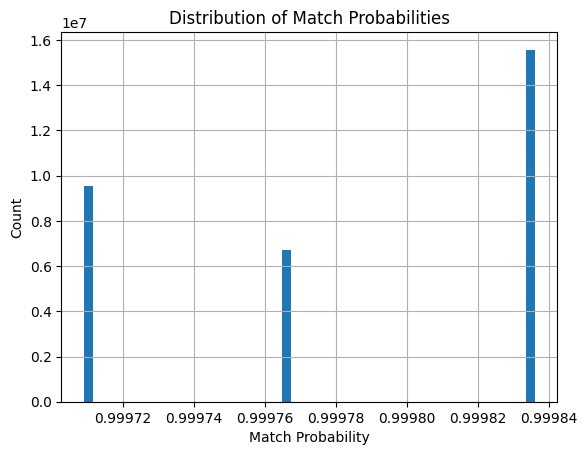

Exact same name matches: 15573349
Different name matches: 16246265

Sample of different name matches:
                       name_consolidated_l                     name_consolidated_r  match_probability
0                   LG Electronics USA Inc  LG Electronics MobileComm U.S.A., Inc.           0.999709
1                   LG Electronics USA Inc  LG Electronics MobileComm U.S.A., Inc.           0.999709
7                   LG Electronics USA Inc  LG Electronics MobileComm U.S.A., Inc.           0.999709
15                        John Does (1-10)                               John Does           0.999709
16                        John Does (1-10)                               John Does           0.999709
20                    LG Electronics, Inc.                  LG Electronics USA Inc           0.999709
21  LG Electronics MobileComm U.S.A., Inc.                  LG Electronics USA Inc           0.999709
22                    LG Electronics, Inc.                  LG Electronics USA Inc

In [29]:
# see distribution of match probabilities
import matplotlib.pyplot as plt

predictions_df['match_probability'].hist(bins=50)
plt.xlabel('Match Probability')
plt.ylabel('Count')
plt.title('Distribution of Match Probabilities')
plt.show()

# check how many are exact same name vs actually different
exact_same = predictions_df[
    predictions_df['name_consolidated_l'] == predictions_df['name_consolidated_r']
]
different_names = predictions_df[
    predictions_df['name_consolidated_l'] != predictions_df['name_consolidated_r']
]

print(f"Exact same name matches: {len(exact_same)}")
print(f"Different name matches: {len(different_names)}")
print(f"\nSample of different name matches:")
print(different_names[['name_consolidated_l', 'name_consolidated_r', 
                         'match_probability']].head(20).to_string())